In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
root = "/content/drive/MyDrive"
for name in sorted(os.listdir(root)):
    print(name)

Mounted at /content/drive
Colab Notebooks
data
water_seg


In [2]:
import shutil
from pathlib import Path

DRIVE_DATA = Path("/content/drive/MyDrive/data")
LOCAL_DATA = Path("/content/data")

img_src, lbl_src = DRIVE_DATA / "images", DRIVE_DATA / "labels"
img_dst, lbl_dst = LOCAL_DATA / "images", LOCAL_DATA / "labels"
img_dst.mkdir(parents=True, exist_ok=True)
lbl_dst.mkdir(parents=True, exist_ok=True)

img_ids = {p.stem for p in img_src.glob("*.tif")}
lbl_ids = {p.stem for p in lbl_src.glob("*.png")}
matched = sorted(img_ids & lbl_ids, key=int)

for i in matched:
    if not (img_dst / f"{i}.tif").exists():
        shutil.copy2(img_src / f"{i}.tif", img_dst / f"{i}.tif")
    if not (lbl_dst / f"{i}.png").exists():
        shutil.copy2(lbl_src / f"{i}.png", lbl_dst / f"{i}.png")

local_imgs = sorted(img_dst.glob("*.tif"))
local_lbls = sorted(lbl_dst.glob("*.png"))
size_mb = sum(p.stat().st_size for p in local_imgs + local_lbls) / 1e6

print("images on Drive:", len(img_ids))
print("labels on Drive:", len(lbl_ids))
print("matched pairs:", len(matched))
print("labels without image:", len(lbl_ids - img_ids))
print("images without label:", len(img_ids - lbl_ids))
print("local images / labels:", len(local_imgs), "/", len(local_lbls))
print(f"local size: {size_mb:.1f} MB")
print("first ids:", matched[:5])

images on Drive: 306
labels on Drive: 456
matched pairs: 306
labels without image: 150
images without label: 0
local images / labels: 306 / 306
local size: 121.0 MB
first ids: ['0', '1', '2', '3', '4']


## 2. Load the data and verify it against the EDA

1. Images are loaded as one int16 array of shape (306, 128, 128, 12), channels-last, in sorted numeric id order.
2. Masks are loaded as one uint8 array of shape (306, 128, 128).
3. Nothing is normalized or cast yet. Raw integers are kept so QA bits and indices can be computed from them later.
4. Checks against the EDA numbers:
   - mask values are only 0 and 1, and the water share is about 25.98%
   - per-band min, max, mean and std match the EDA table
   - Merit DEM is -9999 in 77,704 pixels across 7 images

In [3]:
import numpy as np
import tifffile
from PIL import Image
from pathlib import Path

LOCAL_DATA = Path("/content/data")
img_dst, lbl_dst = LOCAL_DATA / "images", LOCAL_DATA / "labels"

ids = sorted((p.stem for p in img_dst.glob("*.tif")), key=int)

X = np.stack([tifffile.imread(img_dst / f"{i}.tif") for i in ids])
Y = np.stack([np.array(Image.open(lbl_dst / f"{i}.png")) for i in ids])

band_names = ["Coastal", "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2",
              "QA", "MeritDEM", "CopDEM", "ESA", "WaterOcc"]

print("X:", X.shape, X.dtype)
print("Y:", Y.shape, Y.dtype, "values:", np.unique(Y))
print(f"water share: {Y.mean() * 100:.2f}%")
print()
print(f"{'band':10s} {'min':>8s} {'max':>8s} {'mean':>9s} {'std':>8s}")
for c, name in enumerate(band_names):
    b = X[..., c].astype(np.float64)
    print(f"{name:10s} {b.min():8.0f} {b.max():8.0f} {b.mean():9.1f} {b.std():8.1f}")

merit_missing = X[..., 8] == -9999
print()
print("Merit -9999 pixels:", int(merit_missing.sum()))
print("images with Merit -9999:", int(merit_missing.any(axis=(1, 2)).sum()))

X: (306, 128, 128, 12) int16
Y: (306, 128, 128) uint8 values: [0 1]
water share: 25.98%

band            min      max      mean      std
Coastal       -1393     6568     396.5    270.1
Blue          -1169     9659     494.6    326.0
Green          -722    11368     822.3    418.1
Red            -684    12041     973.7    586.7
NIR            -412    15841    2090.1   1056.0
SWIR1          -335    15252    1964.1   1191.4
SWIR2          -258    14647    1351.3    961.8
QA               64      255     102.7     48.8
MeritDEM      -9999     4245     141.8   1365.0
CopDEM            8     4287     300.7    496.0
ESA              10      100      35.1     20.2
WaterOcc          0      111       9.8     27.8

Merit -9999 pixels: 77704
images with Merit -9999: 7


## 3. Load meta.csv and check it against the arrays

1. meta.csv (id, group, water_frac, merit_missing) comes from the EDA and holds the duplicate groups used for the split.
2. Checks:
   - same 306 ids as the loaded arrays, same order
   - water_frac matches the fraction recomputed from the masks
   - merit_missing flags the 7 images with Merit -9999
   - group structure: 36 duplicate groups covering 82 images (29 pairs, 4 triples, 3 groups of four), about 260 unique scenes
3. Any mismatch is resolved before the split is built.

In [4]:
import pandas as pd

meta = pd.read_csv("/content/drive/MyDrive/water_seg/meta.csv")

print(meta.shape)
print(meta.dtypes)
print(meta.head())
print()

meta_ids = meta["id"].astype(str).tolist()
print("same ids, same order:", meta_ids == ids)
print("same id set:", set(meta_ids) == set(ids))

meta = meta.set_index(meta["id"].astype(str)).loc[ids].reset_index(drop=True)

wf = Y.reshape(len(ids), -1).mean(axis=1)
print("max |water_frac diff|:", float(np.abs(meta["water_frac"].to_numpy() - wf).max()))

mm_count = (X[..., 8] == -9999).reshape(len(ids), -1).sum(axis=1)
print("merit_missing unique values:", meta["merit_missing"].unique()[:10])
print("images with merit pixels > 0:", int((mm_count > 0).sum()))
print("meta flagged:", int((meta["merit_missing"] > 0).sum()))
print("flag agrees with recomputed:", bool(((meta["merit_missing"] > 0).to_numpy() == (mm_count > 0)).all()))

sizes = meta.groupby("group").size()
print()
print("unique group values:", meta["group"].nunique())
print("group size counts:")
print(sizes.value_counts().sort_index())
print("images in groups of size >= 2:", int(sizes[sizes >= 2].sum()))

(306, 4)
id                 int64
group              int64
water_frac       float64
merit_missing       bool
dtype: object
   id  group  water_frac  merit_missing
0   0      0    0.117004          False
1   1      1    0.011108          False
2   2      2    0.718262          False
3   3      3    0.053162          False
4   4      4    0.019836          False

same ids, same order: True
same id set: True
max |water_frac diff|: 0.0
merit_missing unique values: [False  True]
images with merit pixels > 0: 7
meta flagged: 7
flag agrees with recomputed: True

unique group values: 260
group size counts:
1    224
2     29
3      4
4      3
Name: count, dtype: int64
images in groups of size >= 2: 82


## 4. Grouped, stratified train/val/test split (70/15/15)

1. The split unit is the duplicate group (260 units), so near-duplicate images never sit in different sets.
2. Each group gets a water bin from the mean water fraction of its images:
   - 0: no water
   - 1: under 5%
   - 2: 5% to 50%
   - 3: over 50%
3. Two stratified splits on groups: 70% train, then the remaining 30% halved into validation and test. Fixed seed 42.
4. The result is saved to MyDrive/water_seg/split.csv (id, group, water_frac, split) so every notebook uses the same split.
5. Checks:
   - no group appears in more than one set
   - image counts, group counts and pixel water share per set
   - bin distribution per set

In [5]:
from sklearn.model_selection import train_test_split

SEED = 42

g = meta.groupby("group").agg(wf=("water_frac", "mean"), n=("id", "size")).reset_index()
g["bin"] = np.select([g["wf"] == 0, g["wf"] < 0.05, g["wf"] <= 0.5], [0, 1, 2], default=3)

g_train, g_rest = train_test_split(g, test_size=0.30, stratify=g["bin"], random_state=SEED)
g_val, g_test = train_test_split(g_rest, test_size=0.50, stratify=g_rest["bin"], random_state=SEED)

split_of = {}
for name, part in [("train", g_train), ("val", g_val), ("test", g_test)]:
    for grp in part["group"]:
        split_of[grp] = name

meta["split"] = meta["group"].map(split_of)
meta["bin"] = meta["group"].map(g.set_index("group")["bin"])

assert meta["split"].notna().all()
assert meta.groupby("group")["split"].nunique().max() == 1

split_path = "/content/drive/MyDrive/water_seg/split.csv"
meta[["id", "group", "water_frac", "split"]].to_csv(split_path, index=False)

rows = []
for name in ["train", "val", "test"]:
    idx = (meta["split"] == name).to_numpy()
    rows.append({
        "split": name,
        "images": int(idx.sum()),
        "groups": int(meta.loc[idx, "group"].nunique()),
        "water_share_%": round(float(Y[idx].mean() * 100), 2),
    })
print(pd.DataFrame(rows).to_string(index=False))
print()
print("images per water bin (0 none, 1 <5%, 2 5-50%, 3 >50%):")
print(pd.crosstab(meta["split"], meta["bin"]).loc[["train", "val", "test"]])

split  images  groups  water_share_%
train     213     182          26.41
  val      47      39          26.31
 test      46      39          23.63

images per water bin (0 none, 1 <5%, 2 5-50%, 3 >50%):
bin     0   1   2   3
split                
train  32  50  83  48
val     6  11  22   8
test    7  11  18  10


## 5. Train-only normalization statistics

1. Statistics come from the 213 training images only, so nothing from validation or test leaks into the scaling.
2. Merit DEM -9999 is filled from Copernicus DEM first (they correlate about 1.0, and Copernicus is valid everywhere). The fill is applied on a copy.
3. For all 12 bands we store min, max, p0.1 and p99.9. This covers the baseline (min-max) and leaves the clipping choice open.
4. Clip bounds for the engineered model: lower 0 and upper p99.9 for Green, NIR and SWIR1.
5. Everything is saved to MyDrive/water_seg/norm_stats.json.
6. Checks:
   - no -9999 left in Merit after the fill
   - train p99.9 close to the whole-dataset values from the EDA (Green 5095, NIR 5399, SWIR1 5147)
   - share of train pixels above the upper clip bound is about 0.1%

In [6]:
import json

train_idx = (meta["split"] == "train").to_numpy()

Xf = X.copy()
miss = Xf[..., 8] == -9999
Xf[..., 8][miss] = Xf[..., 9][miss]
print("Merit -9999 left after fill:", int((Xf[..., 8] == -9999).sum()))

ok = ~miss
d = np.abs(X[..., 8][ok].astype(np.int32) - X[..., 9][ok].astype(np.int32))
print("Merit vs Copernicus abs diff on valid pixels: median", float(np.median(d)), "p99", float(np.percentile(d, 99)))

Xtr = Xf[train_idx]
stats = {}
for c, name in enumerate(band_names):
    v = Xtr[..., c].ravel().astype(np.float32)
    lo, hi = np.percentile(v, [0.1, 99.9])
    stats[name] = {"channel": c, "min": float(v.min()), "max": float(v.max()),
                   "p0.1": float(lo), "p99.9": float(hi)}

clip_bounds = {n: {"lower": 0.0, "upper": stats[n]["p99.9"]} for n in ["Green", "NIR", "SWIR1"]}

out = {"split_file": split_path, "n_train_images": int(train_idx.sum()),
       "bands": stats, "clip_bounds": clip_bounds}
with open("/content/drive/MyDrive/water_seg/norm_stats.json", "w") as f:
    json.dump(out, f, indent=2)

print()
print(pd.DataFrame(stats).T.drop(columns="channel").round(1).to_string())
print()
for n, b in clip_bounds.items():
    c = band_names.index(n)
    share = float((Xtr[..., c] > b["upper"]).mean() * 100)
    print(f"{n}: upper {b['upper']:.0f}, train pixels above: {share:.3f}%")

Merit -9999 left after fill: 0
Merit vs Copernicus abs diff on valid pixels: median 4.0 p99 57.0

             min      max  p0.1   p99.9
Coastal  -1393.0   6568.0 -59.0  4245.0
Blue     -1169.0   9659.0 -24.0  4950.2
Green     -722.0  11368.0  74.0  5613.2
Red       -684.0  12041.0 -50.0  5905.0
NIR       -408.0  15841.0 -89.0  5511.2
SWIR1     -334.0  15252.0 -78.0  5210.0
SWIR2     -258.0  14647.0 -32.0  4423.0
QA          64.0    255.0  64.0   240.0
MeritDEM    -1.0   4245.0  12.0  4152.0
CopDEM       8.0   4287.0  11.0  4190.0
ESA         10.0    100.0  10.0    90.0
WaterOcc     0.0    111.0   0.0    99.0

Green: upper 5613, train pixels above: 0.100%
NIR: upper 5511, train pixels above: 0.100%
SWIR1: upper 5210, train pixels above: 0.100%


## 6. Engineered features (11 channels)

1. Input per sample is the raw (128, 128, 12) int16 array, output is (11, 128, 128) float32.
2. Channel order: Green, NIR, SWIR1, MNDWI, NDWI, QA bit 4, QA bit 5, ESA 80, ESA 40, ESA 10, ESA other.
3. Green, NIR and SWIR1: clip to the saved train bounds (lower 0, upper p99.9), then min-max to [0, 1].
4. MNDWI = (Green - SWIR1) / (Green + SWIR1) and NDWI = (Green - NIR) / (Green + NIR), computed from raw integers cast to float32 and clipped at 0. If both bands are 0 the index is 0. Result is bounded in [-1, 1] by construction.
5. QA bits are extracted from the raw integer (bit 4 = 16, bit 5 = 32). ESA is one-hot, so the four flags sum to 1.
6. Checks:
   - shape (306, 11, 128, 128), no NaN, ranges per channel
   - ESA flags sum to 1
   - QA bit 5, QA bit 4 and ESA 80 reproduce the EDA numbers on the training set
   - MNDWI and NDWI class medians close to the EDA values (MNDWI 0.396 vs -0.508, NDWI 0.175 vs -0.499)

In [7]:
with open("/content/drive/MyDrive/water_seg/norm_stats.json") as f:
    bounds = json.load(f)["clip_bounds"]

feat_names = ["Green", "NIR", "SWIR1", "MNDWI", "NDWI",
              "QA_bit4", "QA_bit5", "ESA_80", "ESA_40", "ESA_10", "ESA_other"]

def norm_index(a, b):
    num = a - b
    den = a + b
    out = np.zeros_like(num, dtype=np.float32)
    np.divide(num, den, out=out, where=den > 0)
    return out

def build_features(x):
    g = np.clip(x[..., 2].astype(np.float32), 0, None)
    n = np.clip(x[..., 4].astype(np.float32), 0, None)
    s = np.clip(x[..., 5].astype(np.float32), 0, None)
    mndwi = norm_index(g, s)
    ndwi = norm_index(g, n)

    scaled = []
    for name, ch in [("Green", 2), ("NIR", 4), ("SWIR1", 5)]:
        lo, hi = bounds[name]["lower"], bounds[name]["upper"]
        band = np.clip(x[..., ch].astype(np.float32), lo, hi)
        scaled.append((band - lo) / (hi - lo))

    qa = x[..., 7].astype(np.int32)
    esa = x[..., 10].astype(np.int32)
    e80, e40, e10 = esa == 80, esa == 40, esa == 10
    other = ~(e80 | e40 | e10)

    chans = scaled + [mndwi, ndwi, (qa >> 4) & 1, (qa >> 5) & 1, e80, e40, e10, other]
    return np.stack([c.astype(np.float32) for c in chans], axis=0)

F = np.stack([build_features(X[i]) for i in range(len(X))])
print("F:", F.shape, F.dtype, "| one sample:", F[0].shape)
print("NaN:", bool(np.isnan(F).any()))
print("ESA flags sum to 1:", bool(np.allclose(F[:, 7:11].sum(axis=1), 1.0)))
print()
print(pd.DataFrame({"min": F.min(axis=(0, 2, 3)), "max": F.max(axis=(0, 2, 3)),
                    "mean": F.mean(axis=(0, 2, 3))}, index=feat_names).round(4).to_string())

yt = Y[train_idx] == 1
Ft = F[train_idx]
print()
for name in ["QA_bit4", "QA_bit5", "ESA_80"]:
    fl = Ft[:, feat_names.index(name)] == 1
    print(f"{name}: flagged pixels that are water {yt[fl].mean() * 100:.1f}%, "
          f"water pixels flagged {fl[yt].mean() * 100:.1f}%")
print()
for name in ["MNDWI", "NDWI"]:
    ch = Ft[:, feat_names.index(name)]
    print(f"{name} median water {np.median(ch[yt]):.3f} | background {np.median(ch[~yt]):.3f}")

F: (306, 11, 128, 128) float32 | one sample: (11, 128, 128)
NaN: False
ESA flags sum to 1: True

           min  max    mean
Green      0.0  1.0  0.1464
NIR        0.0  1.0  0.3793
SWIR1      0.0  1.0  0.3770
MNDWI     -1.0  1.0 -0.2841
NDWI      -1.0  1.0 -0.3509
QA_bit4    0.0  1.0  0.0162
QA_bit5    0.0  1.0  0.1943
ESA_80     0.0  1.0  0.1067
ESA_40     0.0  1.0  0.3669
ESA_10     0.0  1.0  0.2377
ESA_other  0.0  1.0  0.2887

QA_bit4: flagged pixels that are water 45.2%, water pixels flagged 3.1%
QA_bit5: flagged pixels that are water 92.5%, water pixels flagged 67.6%
ESA_80: flagged pixels that are water 99.2%, water pixels flagged 38.1%

MNDWI median water 0.376 | background -0.507
NDWI median water 0.152 | background -0.500


## 8. Augmentation (train only)

1. Random horizontal flip (p = 0.5) followed by a random 90 degree rotation (k uniform in 0 to 3), which gives 8 equally likely orientations.
2. The same transform is applied to the features (11, 128, 128) and the mask (1, 128, 128). Nothing else changes: no value jitter, no resizing.
3. It is a wrapper around the existing dataset, so val and test are untouched. `make_train_loader(False)` gives the no-augmentation run for the ablation.
4. The same wrapper will be reused for the 12-channel baseline.
5. Checks:
   - over 50 random draws the water pixel count, the per-channel sums and the per-channel sums under the mask are unchanged (features and mask moved together)
   - the share of draws that actually change the image (expected about 7/8)
   - all 8 orientations appear about equally often
   - a plot of one sample with 3 augmented versions

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader

class WaterDataset(Dataset):
    def __init__(self, feats, masks):
        self.x = torch.from_numpy(np.ascontiguousarray(feats))
        self.y = torch.from_numpy(masks.astype(np.float32)).unsqueeze(1)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, i):
        return self.x[i], self.y[i]

idx = {s: np.where(meta["split"].to_numpy() == s)[0] for s in ["train", "val", "test"]}
datasets = {s: WaterDataset(F[idx[s]], Y[idx[s]]) for s in idx}

BATCH_SIZE = 16
loaders = {
    "train": DataLoader(datasets["train"], batch_size=BATCH_SIZE, shuffle=True,
                        generator=torch.Generator().manual_seed(SEED)),
    "val": DataLoader(datasets["val"], batch_size=BATCH_SIZE, shuffle=False),
    "test": DataLoader(datasets["test"], batch_size=BATCH_SIZE, shuffle=False),
}

for s, ds in datasets.items():
    per_img = ds.y.mean(dim=(1, 2, 3)).numpy()
    diff = np.abs(per_img - meta["water_frac"].to_numpy()[idx[s]]).max()
    print(f"{s}: {len(ds)} images, x {tuple(ds.x.shape)}, y {tuple(ds.y.shape)}, "
          f"water {ds.y.mean().item() * 100:.2f}%, max |water_frac diff| {diff:.2e}")

xb, yb = next(iter(loaders["train"]))
print()
print("batch x:", tuple(xb.shape), xb.dtype, "| batch y:", tuple(yb.shape), yb.dtype)
print("x range:", xb.min().item(), xb.max().item(), "| y values:", torch.unique(yb).tolist())

train: 213 images, x (213, 11, 128, 128), y (213, 1, 128, 128), water 26.41%, max |water_frac diff| 0.00e+00
val: 47 images, x (47, 11, 128, 128), y (47, 1, 128, 128), water 26.31%, max |water_frac diff| 0.00e+00
test: 46 images, x (46, 11, 128, 128), y (46, 1, 128, 128), water 23.63%, max |water_frac diff| 0.00e+00

batch x: (16, 11, 128, 128) torch.float32 | batch y: (16, 1, 128, 128) torch.float32
x range: -1.0 1.0 | y values: [0.0, 1.0]


alignment checks passed on 50 draws | images changed: 46 / 50
orientations matched: 400 / 400
counts by (flip, rot90 k): {(0, 0): 47, (0, 1): 48, (0, 2): 36, (0, 3): 54, (1, 0): 42, (1, 1): 54, (1, 2): 60, (1, 3): 59}

train dataset: AugmentedView | val dataset: WaterDataset | test dataset: WaterDataset
train batch: (16, 11, 128, 128) (16, 1, 128, 128)


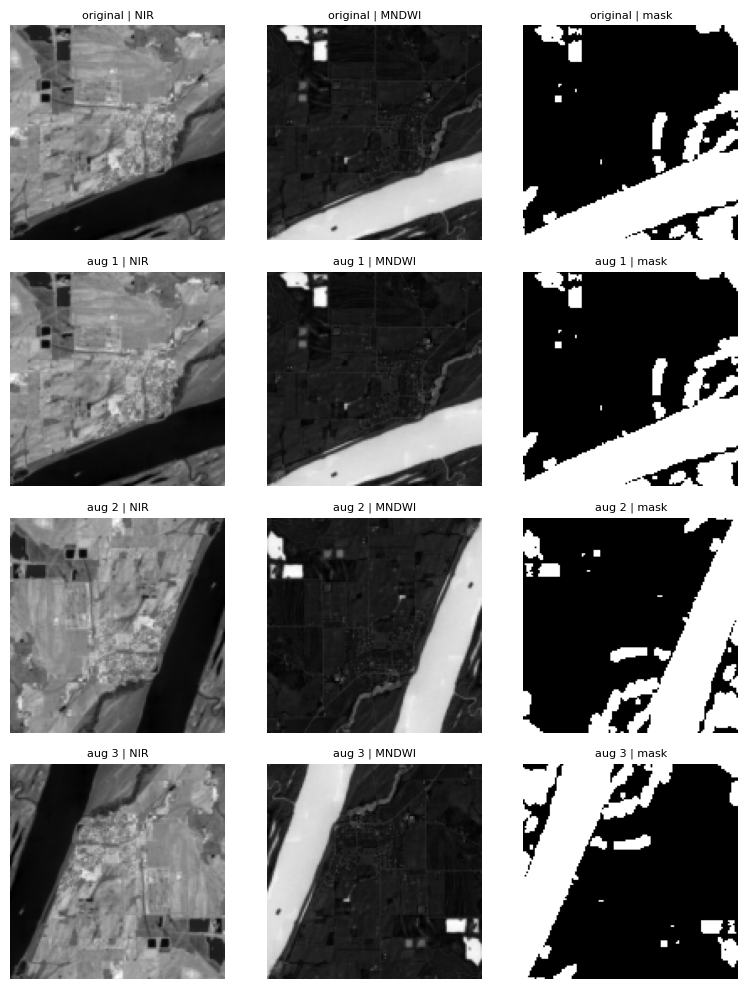

In [9]:
import matplotlib.pyplot as plt

class AugmentedView(Dataset):
    def __init__(self, base, augment=False):
        self.base = base
        self.augment = augment

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        x, y = self.base[i]
        if self.augment:
            if torch.rand(1).item() < 0.5:
                x, y = x.flip(-1), y.flip(-1)
            k = int(torch.randint(0, 4, (1,)).item())
            if k:
                x, y = torch.rot90(x, k, (1, 2)), torch.rot90(y, k, (1, 2))
            x, y = x.contiguous(), y.contiguous()
        return x, y

def make_train_loader(augment, batch_size=BATCH_SIZE):
    ds = AugmentedView(datasets["train"], augment=augment)
    return DataLoader(ds, batch_size=batch_size, shuffle=True,
                      generator=torch.Generator().manual_seed(SEED))

loaders["train"] = make_train_loader(True)

torch.manual_seed(SEED)
plain = datasets["train"]
aug = AugmentedView(plain, augment=True)

n_changed = 0
for _ in range(50):
    i = int(torch.randint(0, len(plain), (1,)).item())
    x0, y0 = plain[i]
    xa, ya = aug[i]
    assert ya.sum() == y0.sum()
    assert torch.allclose(xa.sum(dim=(1, 2)), x0.sum(dim=(1, 2)), rtol=1e-4, atol=1e-3)
    assert torch.allclose((xa * ya).sum(dim=(1, 2)), (x0 * y0).sum(dim=(1, 2)), rtol=1e-4, atol=1e-3)
    n_changed += int(not torch.equal(xa, x0))
print("alignment checks passed on 50 draws | images changed:", n_changed, "/ 50")

wf_train = meta["water_frac"].to_numpy()[idx["train"]]
j = int(np.argmin(np.abs(wf_train - 0.3)))

def dihedral(t, flip, k):
    if flip:
        t = t.flip(-1)
    return torch.rot90(t, k, (1, 2)) if k else t

x0, _ = plain[j]
cands = [(f, k) for f in (0, 1) for k in range(4)]
counts = {c: 0 for c in cands}
for _ in range(400):
    xa, _ = aug[j]
    for c in cands:
        if torch.equal(xa, dihedral(x0, *c)):
            counts[c] += 1
            break
print("orientations matched:", sum(counts.values()), "/ 400")
print("counts by (flip, rot90 k):", counts)

print()
print("train dataset:", type(loaders["train"].dataset).__name__,
      "| val dataset:", type(loaders["val"].dataset).__name__,
      "| test dataset:", type(loaders["test"].dataset).__name__)
xb, yb = next(iter(loaders["train"]))
print("train batch:", tuple(xb.shape), tuple(yb.shape))

samples = [plain[j]] + [aug[j] for _ in range(3)]
titles = ["original", "aug 1", "aug 2", "aug 3"]
fig, axes = plt.subplots(4, 3, figsize=(8, 10))
for r, (xs, ys) in enumerate(samples):
    for c, (arr, name) in enumerate([(xs[1], "NIR"), (xs[3], "MNDWI"), (ys[0], "mask")]):
        axes[r, c].imshow(arr.numpy(), cmap="gray")
        axes[r, c].set_title(f"{titles[r]} | {name}", fontsize=8)
        axes[r, c].axis("off")
plt.tight_layout()
plt.show()

In [10]:
SAVE_DIR = Path("/content/drive/MyDrive/water_seg/data")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

np.save(SAVE_DIR / "features_11.npy", F)
np.save(SAVE_DIR / "masks.npy", Y)
with open(SAVE_DIR / "ids.json", "w") as f:
    json.dump(ids, f)
with open(SAVE_DIR / "feature_names_11.json", "w") as f:
    json.dump(feat_names, f)

F_chk = np.load(SAVE_DIR / "features_11.npy", mmap_mode="r")
Y_chk = np.load(SAVE_DIR / "masks.npy", mmap_mode="r")
ids_chk = json.load(open(SAVE_DIR / "ids.json"))
split_ids = pd.read_csv(split_path)["id"].astype(str).tolist()

for p in sorted(SAVE_DIR.iterdir()):
    print(f"{p.name}: {p.stat().st_size / 1e6:.1f} MB")
print()
print("features:", F_chk.shape, F_chk.dtype, "| identical to memory:", bool(np.array_equal(F_chk, F)))
print("masks:", Y_chk.shape, Y_chk.dtype, "| identical to memory:", bool(np.array_equal(Y_chk, Y)))
print("ids match memory:", ids_chk == ids, "| ids match split.csv order:", split_ids == ids)

feature_names_11.json: 0.0 MB
feature_names_12.json: 0.0 MB
features_11.npy: 220.6 MB
features_12.npy: 240.6 MB
ids.json: 0.0 MB
masks.npy: 5.0 MB

features: (306, 11, 128, 128) float32 | identical to memory: True
masks: (306, 128, 128) uint8 | identical to memory: True
ids match memory: True | ids match split.csv order: True


## 10. 12-channel baseline pipeline

1. Output per sample: (12, 128, 128) float32, channels in the original order (Coastal, Blue, Green, Red, NIR, SWIR1, SWIR2, QA, Merit DEM, Copernicus DEM, ESA, Water occurrence).
2. Merit DEM -9999 is replaced by the Copernicus DEM value at the same pixel before scaling.
3. Per-band, dataset-wide scaling with train-only statistics from norm_stats.json:
   - 9 real-valued bands: clip to [p0.1, p99.9], then min-max
   - QA, ESA, Water occurrence: plain min-max with the train min and max
   - values outside the train range in val and test are clipped to [0, 1]
4. QA, ESA and Water occurrence are treated as plain numbers on purpose. Handling them properly (bit flags, one-hot) is part of the engineered model.
5. Checks:
   - shape (306, 12, 128, 128), no NaN, every channel within [0, 1]
   - filled Merit pixels agree with Copernicus after scaling
   - share of val and test pixels outside the train range for the three plain-scaled channels
6. The array is saved to MyDrive/water_seg/data/features_12.npy and read back for comparison.

In [11]:
with open("/content/drive/MyDrive/water_seg/norm_stats.json") as f:
    band_stats = json.load(f)["bands"]
assert set(band_names) <= set(band_stats)

clip_bands = ["Coastal", "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2", "MeritDEM", "CopDEM"]
plain_bands = ["QA", "ESA", "WaterOcc"]

def build_baseline(x):
    out = np.empty((12, x.shape[0], x.shape[1]), dtype=np.float32)
    for c, name in enumerate(band_names):
        v = x[..., c].astype(np.float32)
        if name == "MeritDEM":
            v = np.where(x[..., 8] == -9999, x[..., 9].astype(np.float32), v)
        if name in clip_bands:
            lo, hi = band_stats[name]["p0.1"], band_stats[name]["p99.9"]
        else:
            lo, hi = band_stats[name]["min"], band_stats[name]["max"]
        out[c] = np.clip((v - lo) / (hi - lo), 0.0, 1.0)
    return out

F12 = np.stack([build_baseline(X[i]) for i in range(len(X))])

print("F12:", F12.shape, F12.dtype, "| NaN:", bool(np.isnan(F12).any()))
print(pd.DataFrame({"min": F12.min(axis=(0, 2, 3)), "max": F12.max(axis=(0, 2, 3)),
                    "mean": F12.mean(axis=(0, 2, 3))}, index=band_names).round(4).to_string())

miss = X[..., 8] == -9999
d = np.abs(F12[:, 8][miss] - F12[:, 9][miss])
print()
print("Merit filled pixels:", int(miss.sum()),
      "| |Merit - Cop| after scaling: mean", round(float(d.mean()), 4), "max", round(float(d.max()), 4))

vt = (meta["split"] != "train").to_numpy()
print()
for name in plain_bands:
    c = band_names.index(name)
    lo, hi = band_stats[name]["min"], band_stats[name]["max"]
    v = X[vt, :, :, c]
    print(f"{name}: val/test pixels outside train range [{lo:.0f}, {hi:.0f}]: "
          f"{((v < lo) | (v > hi)).mean() * 100:.4f}%")

np.save(SAVE_DIR / "features_12.npy", F12)
with open(SAVE_DIR / "feature_names_12.json", "w") as f:
    json.dump(band_names, f)
F12_chk = np.load(SAVE_DIR / "features_12.npy", mmap_mode="r")
print()
print(f"features_12.npy: {(SAVE_DIR / 'features_12.npy').stat().st_size / 1e6:.1f} MB | identical to memory:",
      bool(np.array_equal(F12_chk, F12)))

F12: (306, 12, 128, 128) float32 | NaN: False
          min  max    mean
Coastal   0.0  1.0  0.1057
Blue      0.0  1.0  0.1042
Green     0.0  1.0  0.1350
Red       0.0  1.0  0.1718
NIR       0.0  1.0  0.3891
SWIR1     0.0  1.0  0.3861
SWIR2     0.0  1.0  0.3105
QA        0.0  1.0  0.2028
MeritDEM  0.0  1.0  0.0690
CopDEM    0.0  1.0  0.0693
ESA       0.0  1.0  0.2789
WaterOcc  0.0  1.0  0.0879

Merit filled pixels: 77704 | |Merit - Cop| after scaling: mean 0.0002 max 0.0002

QA: val/test pixels outside train range [64, 255]: 0.0000%
ESA: val/test pixels outside train range [10, 100]: 0.0000%
WaterOcc: val/test pixels outside train range [0, 111]: 0.0000%

features_12.npy: 240.6 MB | identical to memory: True


## 11. Restart kit: reload everything from Drive

1. Run this first after any runtime restart. It mounts Drive and loads features_11.npy, features_12.npy, masks.npy, ids.json, the feature names and split.csv.
2. It redefines WaterDataset and AugmentedView and builds the datasets for both variants once:
   - "engineered": 11 channels
   - "baseline": 12 channels
3. make_loaders(variant, batch_size, augment) creates the loaders. Only the train loader augments, and augment=False gives the ablation run.
4. Checks: GPU status, shapes, no NaN, value ranges, split sizes and water shares, and one batch from each variant.

In [17]:
from google.colab import drive
drive.mount("/content/drive")

import json
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
ROOT = Path("/content/drive/MyDrive/water_seg")
SAVE_DIR = ROOT / "data"
split_path = ROOT / "split.csv"

ids = json.load(open(SAVE_DIR / "ids.json"))
feat_names = json.load(open(SAVE_DIR / "feature_names_11.json"))
band_names = json.load(open(SAVE_DIR / "feature_names_12.json"))
F = np.load(SAVE_DIR / "features_11.npy")
F12 = np.load(SAVE_DIR / "features_12.npy")
Y = np.load(SAVE_DIR / "masks.npy")

meta = pd.read_csv(split_path)
assert meta["id"].astype(str).tolist() == ids
idx = {s: np.where(meta["split"].to_numpy() == s)[0] for s in ["train", "val", "test"]}

class WaterDataset(Dataset):
    def __init__(self, feats, masks):
        self.x = torch.from_numpy(np.ascontiguousarray(feats))
        self.y = torch.from_numpy(masks.astype(np.float32)).unsqueeze(1)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, i):
        return self.x[i], self.y[i]

class AugmentedView(Dataset):
    def __init__(self, base, augment=False):
        self.base = base
        self.augment = augment

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        x, y = self.base[i]
        if self.augment:
            if torch.rand(1).item() < 0.5:
                x, y = x.flip(-1), y.flip(-1)
            k = int(torch.randint(0, 4, (1,)).item())
            if k:
                x, y = torch.rot90(x, k, (1, 2)), torch.rot90(y, k, (1, 2))
            x, y = x.contiguous(), y.contiguous()
        return x, y

FEATURES = {"engineered": F, "baseline": F12}
DATASETS = {v: {s: WaterDataset(FEATURES[v][idx[s]], Y[idx[s]]) for s in idx} for v in FEATURES}

def make_loaders(variant, batch_size=16, augment=True, seed=SEED):
    ds = DATASETS[variant]
    train_ds = AugmentedView(ds["train"], augment=augment)
    return {
        "train": DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                            generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(ds["val"], batch_size=batch_size, shuffle=False),
        "test": DataLoader(ds["test"], batch_size=batch_size, shuffle=False),
    }

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "|", torch.cuda.get_device_name(0) if device.type == "cuda" else "no GPU")
print("F:", F.shape, F.dtype, "| F12:", F12.shape, F12.dtype, "| Y:", Y.shape, Y.dtype)
print("NaN in F / F12:", bool(np.isnan(F).any()), bool(np.isnan(F12).any()))
print("F12 range:", float(F12.min()), float(F12.max()))
print("ESA flags sum to 1:", bool(np.allclose(F[:, 7:11].sum(axis=1), 1.0)))
print()
for s in idx:
    print(f"{s}: {len(idx[s])} images, water {Y[idx[s]].mean() * 100:.2f}%")
print()
for v in FEATURES:
    ld = make_loaders(v)
    xb, yb = next(iter(ld["train"]))
    print(v, "| batch x", tuple(xb.shape), "| batch y", tuple(yb.shape),
          "| val/test sizes", len(ld["val"].dataset), len(ld["test"].dataset))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda | Tesla T4
F: (306, 11, 128, 128) float32 | F12: (306, 12, 128, 128) float32 | Y: (306, 128, 128) uint8
NaN in F / F12: False False
F12 range: 0.0 1.0
ESA flags sum to 1: True

train: 213 images, water 26.41%
val: 47 images, water 26.31%
test: 46 images, water 23.63%

engineered | batch x (16, 11, 128, 128) | batch y (16, 1, 128, 128) | val/test sizes 47 46
baseline | batch x (16, 12, 128, 128) | batch y (16, 1, 128, 128) | val/test sizes 47 46


## 12. U-Net from scratch

1. Architecture: four down levels with max pooling, a bottleneck, and four up levels with transposed convolutions. Each level is two 3x3 convolutions with BatchNorm and ReLU. Skip connections concatenate the encoder features into the decoder.
2. Parameters: in_ch (11 for the engineered input, 12 for the baseline) and base (width of the first level, doubled at each level). No pretrained weights.
3. Output: one logit per pixel, shape (B, 1, 128, 128). The sigmoid is left to the loss and to prediction time.
4. Checks:
   - output shape for both variants, finite values, and the initial BCE (about 0.69 for a model that outputs near zero)
   - gradients reach the first layer
   - parameter counts for base 16, 32 and 64
   - an overfit test on 8 images: the loss must fall clearly, which proves the model can learn

In [18]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_ch, base=32, n_out=1):
        super().__init__()
        c = [base, base * 2, base * 4, base * 8, base * 16]
        self.enc1 = DoubleConv(in_ch, c[0])
        self.enc2 = DoubleConv(c[0], c[1])
        self.enc3 = DoubleConv(c[1], c[2])
        self.enc4 = DoubleConv(c[2], c[3])
        self.bottleneck = DoubleConv(c[3], c[4])
        self.pool = nn.MaxPool2d(2)
        self.up4 = nn.ConvTranspose2d(c[4], c[3], 2, stride=2)
        self.dec4 = DoubleConv(c[3] * 2, c[3])
        self.up3 = nn.ConvTranspose2d(c[3], c[2], 2, stride=2)
        self.dec3 = DoubleConv(c[2] * 2, c[2])
        self.up2 = nn.ConvTranspose2d(c[2], c[1], 2, stride=2)
        self.dec2 = DoubleConv(c[1] * 2, c[1])
        self.up1 = nn.ConvTranspose2d(c[1], c[0], 2, stride=2)
        self.dec1 = DoubleConv(c[0] * 2, c[0])
        self.head = nn.Conv2d(c[0], n_out, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
torch.manual_seed(SEED)

tr = idx["train"][:8]
x11 = torch.from_numpy(F[tr]).to(device)
x12 = torch.from_numpy(F12[tr]).to(device)
y8 = torch.from_numpy(Y[tr].astype(np.float32)).unsqueeze(1).to(device)
bce = nn.BCEWithLogitsLoss()

print()
for name, in_ch, x in [("engineered", 11, x11), ("baseline", 12, x12)]:
    model = UNet(in_ch, base=32).to(device)
    out = model(x)
    loss = bce(out, y8)
    loss.backward()
    grad = model.enc1.block[0].weight.grad
    grad_ok = bool(torch.isfinite(grad).all() and grad.abs().sum() > 0)
    print(f"{name}: in {tuple(x.shape)} -> out {tuple(out.shape)} | params {count_params(model) / 1e6:.2f}M | "
          f"finite {bool(torch.isfinite(out).all())} | initial BCE {loss.item():.3f} | first-layer grad ok {grad_ok}")

print()
for base in [16, 32, 64]:
    print(f"base {base}: {count_params(UNet(11, base)) / 1e6:.2f}M parameters")

print()
model = UNet(11, base=32).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
for step in range(60):
    opt.zero_grad()
    loss = bce(model(x11), y8)
    loss.backward()
    opt.step()
    if step in (0, 20, 40, 59):
        print(f"overfit test, step {step}: BCE {loss.item():.4f}")

device: cuda

engineered: in (8, 11, 128, 128) -> out (8, 1, 128, 128) | params 7.77M | finite True | initial BCE 0.731 | first-layer grad ok True
baseline: in (8, 12, 128, 128) -> out (8, 1, 128, 128) | params 7.77M | finite True | initial BCE 0.719 | first-layer grad ok True

base 16: 1.94M parameters
base 32: 7.77M parameters
base 64: 31.04M parameters

overfit test, step 0: BCE 0.5875
overfit test, step 20: BCE 0.2564
overfit test, step 40: BCE 0.1927
overfit test, step 59: BCE 0.1485


## 13. Loss and metrics

1. Loss: BCE with logits plus dice_weight times a soft Dice term. dice_weight = 0 gives plain BCE. Dice is pooled over the batch, so images without water do not cause a 0/0 problem.
2. Metrics on the water class, pooled over all pixels of the evaluated set (TP, FP and FN summed over images), at threshold 0.5:
   - IoU = TP / (TP + FP + FN)
   - precision = TP / (TP + FP)
   - recall = TP / (TP + FN)
   - F1 = 2 TP / (2 TP + FP + FN)
3. Per-image counts are kept, so the same predictions can also be scored without the full-water images (more than 95% water pixels in the image).
4. evaluate() returns loss, IoU, precision, recall, F1 and IoU without full-water images.
5. Checks:
   - a hand-made toy example with known counts (TP 1, FP 1, FN 1 gives IoU 1/3, precision 0.5, recall 0.5, F1 0.5)
   - agreement with scikit-learn on random predictions
   - loss values for perfect, uninformative and inverted logits
   - a plumbing run on an untrained model for both variants (the numbers themselves mean nothing)

In [19]:
import torch.nn.functional as nnf
from sklearn.metrics import f1_score, precision_score, recall_score, jaccard_score

def loss_fn(logits, y, dice_weight=0.0):
    loss = nnf.binary_cross_entropy_with_logits(logits, y)
    if dice_weight > 0:
        p = torch.sigmoid(logits)
        inter = (p * y).sum()
        dice = (2 * inter + 1.0) / (p.sum() + y.sum() + 1.0)
        loss = loss + dice_weight * (1.0 - dice)
    return loss

@torch.no_grad()
def collect(model, loader, device):
    model.eval()
    logits, ys = [], []
    for x, y in loader:
        logits.append(model(x.to(device)).float().cpu())
        ys.append(y)
    return torch.cat(logits), torch.cat(ys)

def image_counts(logits, y, threshold=0.5):
    pred = torch.sigmoid(logits) > threshold
    t = y > 0.5
    tp = (pred & t).sum(dim=(1, 2, 3))
    fp = (pred & ~t).sum(dim=(1, 2, 3))
    fn = (~pred & t).sum(dim=(1, 2, 3))
    return torch.stack([tp, fp, fn], dim=1).double().numpy()

def summarize(counts, mask=None):
    c = counts if mask is None else counts[mask]
    tp, fp, fn = c.sum(axis=0)
    return {"iou": tp / max(tp + fp + fn, 1),
            "precision": tp / max(tp + fp, 1),
            "recall": tp / max(tp + fn, 1),
            "f1": 2 * tp / max(2 * tp + fp + fn, 1)}

def evaluate(model, loader, device, dice_weight=0.0, threshold=0.5, full_water=None):
    logits, y = collect(model, loader, device)
    counts = image_counts(logits, y, threshold)
    out = {"loss": loss_fn(logits, y, dice_weight).item(), **summarize(counts)}
    if full_water is not None:
        out["iou_excl_full"] = summarize(counts, ~full_water)["iou"]
    return out

FULL_WATER = 0.95
wf_all = meta["water_frac"].to_numpy()
full_flags = {s: wf_all[idx[s]] > FULL_WATER for s in idx}
print("images above 95% water:", {s: int(v.sum()) for s, v in full_flags.items()})

toy_logits = torch.tensor([[[[5.0, -5.0, 5.0, -5.0]]]])
toy_y = torch.tensor([[[[1.0, 1.0, 0.0, 0.0]]]])
toy = summarize(image_counts(toy_logits, toy_y))
print()
print("toy:", {k: round(float(v), 4) for k, v in toy.items()})
assert abs(toy["iou"] - 1 / 3) < 1e-9 and abs(toy["precision"] - 0.5) < 1e-9
assert abs(toy["recall"] - 0.5) < 1e-9 and abs(toy["f1"] - 0.5) < 1e-9

rng = np.random.default_rng(0)
r_logits = torch.tensor(rng.normal(size=(20, 1, 128, 128)), dtype=torch.float32)
r_y = torch.tensor(rng.random((20, 1, 128, 128)) < 0.26).float()
mine = summarize(image_counts(r_logits, r_y))
truth = r_y.numpy().ravel().astype(int)
pred = (r_logits > 0).numpy().ravel().astype(int)
ref = {"iou": jaccard_score(truth, pred), "precision": precision_score(truth, pred),
       "recall": recall_score(truth, pred), "f1": f1_score(truth, pred)}
print("max |mine - sklearn|:", max(abs(mine[k] - ref[k]) for k in ref))

print()
y_ref = r_y
for name, lg in [("perfect", (y_ref * 2 - 1) * 20), ("uninformative", torch.zeros_like(y_ref)),
                 ("inverted", (1 - y_ref * 2) * 20)]:
    print(f"{name:14s} BCE {loss_fn(lg, y_ref, 0.0).item():8.4f} | BCE+Dice(1.0) {loss_fn(lg, y_ref, 1.0).item():8.4f}")

print()
for v, in_ch in [("engineered", 11), ("baseline", 12)]:
    m = UNet(in_ch, base=32).to(device)
    ld = make_loaders(v)
    r = evaluate(m, ld["val"], device, dice_weight=0.0, full_water=full_flags["val"])
    print(v, "(untrained):", {k: round(float(val), 4) for k, val in r.items()})

images above 95% water: {'train': 8, 'val': 2, 'test': 0}

toy: {'iou': 0.3333, 'precision': 0.5, 'recall': 0.5, 'f1': 0.5}
max |mine - sklearn|: 0.0

perfect        BCE   0.0000 | BCE+Dice(1.0)   0.0000
uninformative  BCE   0.6931 | BCE+Dice(1.0)   1.3512
inverted       BCE  20.0000 | BCE+Dice(1.0)  21.0000

engineered (untrained): {'loss': 0.6717, 'iou': 0.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'iou_excl_full': 0.0}
baseline (untrained): {'loss': 0.7257, 'iou': 0.2631, 'precision': 0.2631, 'recall': 1.0, 'f1': 0.4166, 'iou_excl_full': 0.2303}


In [22]:
import copy

RUNS_DIR = ROOT / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

def run_paths(run_name):
    d = RUNS_DIR / run_name
    d.mkdir(parents=True, exist_ok=True)
    return d / "last.pt", d / "best.pt"

def new_state():
    return {"epoch": 0, "best_metric": -1.0, "best_epoch": 0, "bad_epochs": 0,
            "finished": False, "history": []}

def cfg_core(cfg):
    return {k: v for k, v in cfg.items() if k != "max_epochs"}

def rng_snapshot():
    return {"torch": torch.get_rng_state(), "numpy": np.random.get_state(), "python": random.getstate()}

def rng_restore(s):
    torch.set_rng_state(s["torch"].cpu())
    np.random.set_state(s["numpy"])
    random.setstate(s["python"])

def atomic_save(obj, path):
    tmp = path.with_suffix(".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)

def save_checkpoint(run_name, model, optimizer, scheduler, state, cfg):
    last_path, _ = run_paths(run_name)
    atomic_save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                 "scheduler": scheduler.state_dict(), "state": copy.deepcopy(state),
                 "cfg": cfg, "rng": rng_snapshot()}, last_path)

def save_best(run_name, model, state, cfg):
    _, best_path = run_paths(run_name)
    atomic_save({"model": model.state_dict(), "epoch": state["best_epoch"],
                 "best_metric": state["best_metric"], "cfg": cfg}, best_path)

def try_resume(run_name, model, optimizer, scheduler, cfg, device):
    last_path, _ = run_paths(run_name)
    if not last_path.exists():
        print(f"[{run_name}] no checkpoint, starting fresh")
        return new_state()
    ckpt = torch.load(last_path, map_location=device, weights_only=False)
    if cfg_core(ckpt["cfg"]) != cfg_core(cfg):
        diff = {k: (ckpt["cfg"].get(k), cfg.get(k)) for k in set(ckpt["cfg"]) | set(cfg)
                if k != "max_epochs" and ckpt["cfg"].get(k) != cfg.get(k)}
        raise ValueError(f"[{run_name}] config differs from checkpoint (saved, new): {diff}")
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    rng_restore(ckpt["rng"])
    print(f"[{run_name}] resumed after epoch {ckpt['state']['epoch']}")
    return ckpt["state"]

test_cfg = {"variant": "baseline", "in_ch": 12, "base": 8, "lr": 1e-3, "weight_decay": 1e-4,
            "batch_size": 16, "dice_weight": 0.0, "augment": True, "seed": SEED,
            "max_epochs": 5, "patience": 15}
shutil.rmtree(RUNS_DIR / "ckpt_test", ignore_errors=True)

torch.manual_seed(0)
m1 = UNet(12, base=8).to(device)
o1 = torch.optim.AdamW(m1.parameters(), lr=1e-3)
s1 = torch.optim.lr_scheduler.ReduceLROnPlateau(o1, mode="max", factor=0.5, patience=5)
st = new_state()
st.update(epoch=3, best_metric=0.5, best_epoch=2, bad_epochs=1)
st["history"].append({"epoch": 3, "iou": 0.5})
save_checkpoint("ckpt_test", m1, o1, s1, st, test_cfg)
save_best("ckpt_test", m1, st, test_cfg)

torch.manual_seed(1)
m2 = UNet(12, base=8).to(device)
o2 = torch.optim.AdamW(m2.parameters(), lr=1e-3)
s2 = torch.optim.lr_scheduler.ReduceLROnPlateau(o2, mode="max", factor=0.5, patience=5)
st2 = try_resume("ckpt_test", m2, o2, s2, {**test_cfg, "max_epochs": 9}, device)

same_w = all(torch.equal(a, b) for a, b in zip(m1.state_dict().values(), m2.state_dict().values()))
print("weights identical:", same_w, "| state identical:", st2 == st)

try:
    try_resume("ckpt_test", m2, o2, s2, {**test_cfg, "lr": 5e-4}, device)
    print("config mismatch NOT caught")
except ValueError:
    print("config mismatch caught")

print("files:", sorted(p.name for p in (RUNS_DIR / "ckpt_test").iterdir()))
print("fresh start works:", try_resume("ckpt_test_none", m2, o2, s2, test_cfg, device) == new_state())

shutil.rmtree(RUNS_DIR / "ckpt_test", ignore_errors=True)
shutil.rmtree(RUNS_DIR / "ckpt_test_none", ignore_errors=True)

[ckpt_test] resumed after epoch 3
weights identical: True | state identical: True
config mismatch caught
files: ['best.pt', 'last.pt']
[ckpt_test_none] no checkpoint, starting fresh
fresh start works: True


## 14. Trainer with early stopping and checkpoint resume

1. fit(run_name, cfg, save=True) builds the model, AdamW and a ReduceLROnPlateau scheduler on val IoU (factor 0.5, patience 5), then calls try_resume: a fresh start if no checkpoint exists, otherwise it continues from last.pt.
2. Each epoch: train on the augmented train loader, evaluate on val, step the scheduler, update early stopping on pooled val IoU (minimum gain 1e-4, patience 15, max 100 epochs).
3. Saved to Drive: best.pt whenever val IoU improves and last.pt every epoch. A run that stopped at max_epochs can be extended by raising max_epochs and calling fit again.
4. The shuffle order of each epoch is seeded with seed + epoch, so a resumed run follows the same order as an uninterrupted one. Augmentation randomness comes back from the checkpoint's RNG state.
5. At the end the best weights are reloaded and scored on val: loss, IoU, precision, recall, F1 and IoU without full-water images. This is the validation IoU to report. A result.json is written to the run folder. The test set is never touched here.
6. save=False skips all disk writes (for tuning trials).
7. Smoke test: a 2-epoch run, then the same run name with max_epochs=3 must resume at epoch 2 and run only epoch 3. The smoke folder is deleted afterwards.

In [25]:
import time
from tqdm.auto import tqdm

assert "try_resume" in globals() and "save_checkpoint" in globals(), "run the checkpoint cell first"

def build(cfg):
    model = UNet(cfg["in_ch"], base=cfg["base"]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
    return model, optimizer, scheduler

def train_epoch(model, loader, optimizer, dice_weight):
    model.train()
    total, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(model(x), y, dice_weight)
        loss.backward()
        optimizer.step()
        total += loss.item() * x.shape[0]
        n += x.shape[0]
    return total / n

def fit(run_name, cfg, save=True, verbose=True):
    torch.manual_seed(cfg["seed"])
    np.random.seed(cfg["seed"])
    random.seed(cfg["seed"])
    model, optimizer, scheduler = build(cfg)
    lds = make_loaders(cfg["variant"], cfg["batch_size"], cfg["augment"], cfg["seed"])
    full = full_flags["val"]
    state = try_resume(run_name, model, optimizer, scheduler, cfg, device) if save else new_state()
    if state["finished"] and state["bad_epochs"] < cfg["patience"] and state["epoch"] < cfg["max_epochs"]:
        state["finished"] = False

    bar = tqdm(range(state["epoch"] + 1, cfg["max_epochs"] + 1), desc=run_name, disable=not verbose)
    for epoch in bar:
        if state["finished"]:
            break
        t0 = time.time()
        lds["train"].sampler.generator.manual_seed(cfg["seed"] + epoch)
        tr_loss = train_epoch(model, lds["train"], optimizer, cfg["dice_weight"])
        val = evaluate(model, lds["val"], device, cfg["dice_weight"], full_water=full)
        lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val["iou"])
        improved = val["iou"] > state["best_metric"] + 1e-4
        if improved:
            state.update(best_metric=float(val["iou"]), best_epoch=epoch, bad_epochs=0)
        else:
            state["bad_epochs"] += 1
        state["epoch"] = epoch
        state["finished"] = state["bad_epochs"] >= cfg["patience"] or epoch >= cfg["max_epochs"]
        state["history"].append({"epoch": epoch, "train_loss": tr_loss, "lr": lr,
                                 **{k: float(v) for k, v in val.items()}})
        if save:
            if improved:
                save_best(run_name, model, state, cfg)
            save_checkpoint(run_name, model, optimizer, scheduler, state, cfg)
        if verbose:
            bar.set_postfix(val_iou=f"{val['iou']:.4f}", best=f"{state['best_metric']:.4f}",
                            stop=f"{state['bad_epochs']}/{cfg['patience']}")
            tqdm.write(f"ep {epoch:3d} | train {tr_loss:.4f} | val loss {val['loss']:.4f} | IoU {val['iou']:.4f} "
                       f"P {val['precision']:.3f} R {val['recall']:.3f} F1 {val['f1']:.3f} | "
                       f"IoU-noFull {val['iou_excl_full']:.4f} | lr {lr:.1e} | {time.time() - t0:.1f}s"
                       f"{' *' if improved else ''}")

    final = None
    if save:
        last_path, best_path = run_paths(run_name)
        if best_path.exists():
            model.load_state_dict(torch.load(best_path, map_location=device, weights_only=False)["model"])
            final = evaluate(model, lds["val"], device, cfg["dice_weight"], full_water=full)
            print(f"[{run_name}] FINAL best epoch {state['best_epoch']} | val IoU {final['iou']:.4f} | "
                  f"precision {final['precision']:.4f} | recall {final['recall']:.4f} | F1 {final['f1']:.4f} | "
                  f"IoU without full-water {final['iou_excl_full']:.4f}")
            print(f"[{run_name}] matches best IoU in history:", abs(final["iou"] - state["best_metric"]) < 1e-3)
            with open(last_path.parent / "result.json", "w") as f:
                json.dump({"run": run_name, "config": cfg, "best_epoch": state["best_epoch"],
                           "epochs_run": state["epoch"], "val": {k: float(v) for k, v in final.items()}},
                          f, indent=2)
    return {"state": state, "final": final, "model": model}

def plot_history(state, title):
    h = pd.DataFrame(state["history"])
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    ax[0].plot(h["epoch"], h["train_loss"], label="train")
    ax[0].plot(h["epoch"], h["loss"], label="val")
    ax[0].set_title("loss")
    ax[0].legend()
    ax[1].plot(h["epoch"], h["iou"])
    ax[1].axvline(state["best_epoch"], color="gray", linestyle="--")
    ax[1].set_title("val IoU")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

[baseline_s42] no checkpoint, starting fresh


baseline_s42:   0%|          | 0/100 [00:00<?, ?it/s]

ep   1 | train 0.4451 | val loss 0.4929 | IoU 0.3808 P 1.000 R 0.381 F1 0.552 | IoU-noFull 0.2732 | lr 1.0e-03 | 2.6s *
ep   2 | train 0.3543 | val loss 0.3650 | IoU 0.7165 P 0.971 R 0.732 F1 0.835 | IoU-noFull 0.6633 | lr 1.0e-03 | 2.0s *
ep   3 | train 0.3176 | val loss 0.2688 | IoU 0.7440 P 0.935 R 0.784 F1 0.853 | IoU-noFull 0.6976 | lr 1.0e-03 | 2.3s *
ep   4 | train 0.3005 | val loss 0.2876 | IoU 0.7048 P 0.816 R 0.838 F1 0.827 | IoU-noFull 0.6583 | lr 1.0e-03 | 1.8s
ep   5 | train 0.2785 | val loss 0.2606 | IoU 0.7226 P 0.844 R 0.834 F1 0.839 | IoU-noFull 0.6773 | lr 1.0e-03 | 2.1s
ep   6 | train 0.2768 | val loss 0.3161 | IoU 0.6831 P 0.757 R 0.875 F1 0.812 | IoU-noFull 0.6373 | lr 1.0e-03 | 2.0s
ep   7 | train 0.2628 | val loss 0.2212 | IoU 0.7354 P 0.883 R 0.815 F1 0.848 | IoU-noFull 0.6902 | lr 1.0e-03 | 2.2s
ep   8 | train 0.2600 | val loss 0.2140 | IoU 0.7484 P 0.919 R 0.801 F1 0.856 | IoU-noFull 0.7036 | lr 1.0e-03 | 2.3s *
ep   9 | train 0.2553 | val loss 0.2917 | IoU 0.

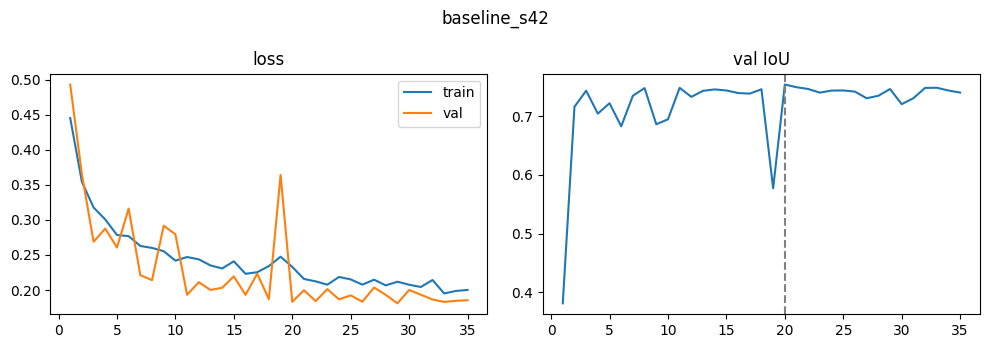

[engineered_s42] no checkpoint, starting fresh


engineered_s42:   0%|          | 0/100 [00:00<?, ?it/s]

ep   1 | train 0.4316 | val loss 0.4126 | IoU 0.6723 P 0.837 R 0.774 F1 0.804 | IoU-noFull 0.6188 | lr 1.0e-03 | 1.9s *
ep   2 | train 0.3512 | val loss 0.3235 | IoU 0.6706 P 0.777 R 0.831 F1 0.803 | IoU-noFull 0.6211 | lr 1.0e-03 | 1.8s
ep   3 | train 0.3218 | val loss 0.2856 | IoU 0.7509 P 0.916 R 0.806 F1 0.858 | IoU-noFull 0.7067 | lr 1.0e-03 | 2.2s *
ep   4 | train 0.3054 | val loss 0.2762 | IoU 0.7536 P 0.923 R 0.805 F1 0.860 | IoU-noFull 0.7097 | lr 1.0e-03 | 2.2s *
ep   5 | train 0.2827 | val loss 0.2959 | IoU 0.7528 P 0.913 R 0.811 F1 0.859 | IoU-noFull 0.7091 | lr 1.0e-03 | 2.4s
ep   6 | train 0.2767 | val loss 0.2835 | IoU 0.7583 P 0.926 R 0.807 F1 0.863 | IoU-noFull 0.7150 | lr 1.0e-03 | 2.1s *
ep   7 | train 0.2671 | val loss 0.2439 | IoU 0.7384 P 0.879 R 0.822 F1 0.850 | IoU-noFull 0.6939 | lr 1.0e-03 | 1.8s
ep   8 | train 0.2636 | val loss 0.2271 | IoU 0.7521 P 0.918 R 0.806 F1 0.859 | IoU-noFull 0.7080 | lr 1.0e-03 | 2.1s
ep   9 | train 0.2608 | val loss 0.2067 | IoU 0.

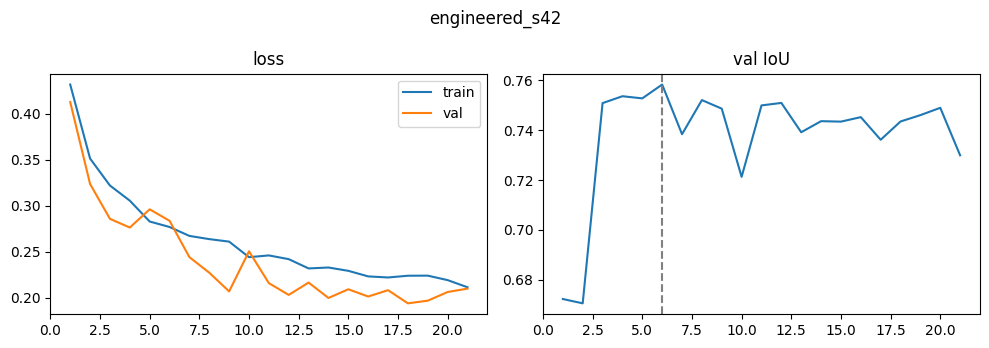


           run  best_epoch  epochs_run   loss    iou  precision  recall     f1  iou_excl_full
  baseline_s42          20          35 0.1831 0.7545     0.9189  0.8083 0.8601         0.7108
engineered_s42           6          21 0.2835 0.7583     0.9260  0.8072 0.8626         0.7150


In [26]:
cfg_base = {"variant": "baseline", "in_ch": 12, "base": 32, "lr": 1e-3, "weight_decay": 1e-4,
            "batch_size": 16, "dice_weight": 0.0, "augment": True, "seed": SEED,
            "max_epochs": 100, "patience": 15}
cfg_eng = {**cfg_base, "variant": "engineered", "in_ch": 11}

res = {}
for name, cfg in [("baseline_s42", cfg_base), ("engineered_s42", cfg_eng)]:
    res[name] = fit(name, cfg)
    plot_history(res[name]["state"], name)

rows = []
for name, r in res.items():
    rows.append({"run": name, "best_epoch": r["state"]["best_epoch"], "epochs_run": r["state"]["epoch"],
                 **{k: round(float(v), 4) for k, v in r["final"].items()}})
print()
print(pd.DataFrame(rows).to_string(index=False))

In [27]:
SEEDS = [42, 43, 44, 45, 46]
cfg_base = {"variant": "baseline", "in_ch": 12, "base": 32, "lr": 1e-3, "weight_decay": 1e-4,
            "batch_size": 16, "dice_weight": 0.0, "augment": True, "seed": 42,
            "max_epochs": 100, "patience": 15}
cfg_eng = {**cfg_base, "variant": "engineered", "in_ch": 11}

metrics = ["iou", "precision", "recall", "f1", "iou_excl_full"]
rows = []
for s in SEEDS:
    for tag, base_cfg in [("baseline", cfg_base), ("engineered", cfg_eng)]:
        r = fit(f"{tag}_s{s}", {**base_cfg, "seed": s})
        rows.append({"variant": tag, "seed": s, "best_epoch": r["state"]["best_epoch"],
                     "epochs_run": r["state"]["epoch"], **{k: float(r["final"][k]) for k in metrics}})

df = pd.DataFrame(rows)
df.to_csv(ROOT / "seed_results.csv", index=False)

print()
print(df.round(4).to_string(index=False))
print()
print(df.groupby("variant")[metrics].agg(["mean", "std"]).round(4).to_string())

piv = df.pivot(index="seed", columns="variant", values="iou")
diff = piv["engineered"] - piv["baseline"]
print()
print("IoU gap per seed (engineered - baseline):", diff.round(4).tolist())
print("mean gap:", round(float(diff.mean()), 4), "| std of gap:", round(float(diff.std()), 4))

[baseline_s42] resumed after epoch 35


baseline_s42:   0%|          | 0/65 [00:00<?, ?it/s]

[baseline_s42] FINAL best epoch 20 | val IoU 0.7545 | precision 0.9189 | recall 0.8083 | F1 0.8601 | IoU without full-water 0.7108
[baseline_s42] matches best IoU in history: True
[engineered_s42] resumed after epoch 21


engineered_s42:   0%|          | 0/79 [00:00<?, ?it/s]

[engineered_s42] FINAL best epoch 6 | val IoU 0.7583 | precision 0.9260 | recall 0.8072 | F1 0.8626 | IoU without full-water 0.7150
[engineered_s42] matches best IoU in history: True
[baseline_s43] no checkpoint, starting fresh


...

ep   1 | train 0.4378 | val loss 0.4268 | IoU 0.7510 P 0.939 R 0.789 F1 0.858 | IoU-noFull 0.7057 | lr 1.0e-03 | 2.0s *
ep   2 | train 0.3326 | val loss 0.2941 | IoU 0.7517 P 0.895 R 0.824 F1 0.858 | IoU-noFull 0.7087 | lr 1.0e-03 | 2.0s *
ep   3 | train 0.3179 | val loss 0.3136 | IoU 0.7516 P 0.894 R 0.825 F1 0.858 | IoU-noFull 0.7086 | lr 1.0e-03 | 1.9s
ep   4 | train 0.2905 | val loss 0.2644 | IoU 0.7502 P 0.906 R 0.813 F1 0.857 | IoU-noFull 0.7064 | lr 1.0e-03 | 2.1s
ep   5 | train 0.2759 | val loss 0.2281 | IoU 0.7503 P 0.910 R 0.810 F1 0.857 | IoU-noFull 0.7063 | lr 1.0e-03 | 1.8s
ep   6 | train 0.2698 | val loss 0.2401 | IoU 0.7512 P 0.905 R 0.816 F1 0.858 | IoU-noFull 0.7077 | lr 1.0e-03 | 1.8s
ep   7 | train 0.2541 | val loss 0.2657 | IoU 0.7509 P 0.896 R 0.823 F1 0.858 | IoU-noFull 0.7078 | lr 1.0e-03 | 2.1s
ep   8 | train 0.2544 | val loss 0.2055 | IoU 0.7519 P 0.917 R 0.807 F1 0.858 | IoU-noFull 0.7079 | lr 1.0e-03 | 2.0s *
ep   9 | train 0.2431 | val loss 0.2118 | IoU 0.74

baseline_s46:   0%|          | 0/100 [00:00<?, ?it/s]

ep   1 | train 0.4215 | val loss 0.5028 | IoU 0.4097 P 1.000 R 0.410 F1 0.581 | IoU-noFull 0.2993 | lr 1.0e-03 | 1.9s *
ep   2 | train 0.3520 | val loss 0.3172 | IoU 0.6852 P 0.980 R 0.695 F1 0.813 | IoU-noFull 0.6255 | lr 1.0e-03 | 1.9s *
ep   3 | train 0.3219 | val loss 0.2681 | IoU 0.7385 P 0.933 R 0.780 F1 0.850 | IoU-noFull 0.6912 | lr 1.0e-03 | 2.6s *
ep   4 | train 0.3042 | val loss 0.2480 | IoU 0.7481 P 0.955 R 0.776 F1 0.856 | IoU-noFull 0.7016 | lr 1.0e-03 | 2.1s *
ep   5 | train 0.2921 | val loss 0.2761 | IoU 0.7322 P 0.850 R 0.841 F1 0.845 | IoU-noFull 0.6883 | lr 1.0e-03 | 1.9s
ep   6 | train 0.2704 | val loss 0.2382 | IoU 0.7434 P 0.881 R 0.827 F1 0.853 | IoU-noFull 0.6997 | lr 1.0e-03 | 1.8s
ep   7 | train 0.2694 | val loss 0.2283 | IoU 0.7488 P 0.896 R 0.821 F1 0.856 | IoU-noFull 0.7053 | lr 1.0e-03 | 2.2s *
ep   8 | train 0.2611 | val loss 0.2598 | IoU 0.7195 P 0.832 R 0.842 F1 0.837 | IoU-noFull 0.6745 | lr 1.0e-03 | 1.8s
ep   9 | train 0.2516 | val loss 0.1956 | IoU 

engineered_s46:   0%|          | 0/100 [00:00<?, ?it/s]

ep   1 | train 0.4132 | val loss 0.5432 | IoU 0.5312 P 0.565 R 0.900 F1 0.694 | IoU-noFull 0.4818 | lr 1.0e-03 | 1.9s *
ep   2 | train 0.3305 | val loss 0.2867 | IoU 0.7281 P 0.853 R 0.833 F1 0.843 | IoU-noFull 0.6833 | lr 1.0e-03 | 2.0s *
ep   3 | train 0.2956 | val loss 0.3007 | IoU 0.6784 P 0.762 R 0.860 F1 0.808 | IoU-noFull 0.6313 | lr 1.0e-03 | 1.8s
ep   4 | train 0.2789 | val loss 0.2317 | IoU 0.7466 P 0.907 R 0.809 F1 0.855 | IoU-noFull 0.7022 | lr 1.0e-03 | 2.0s *
ep   5 | train 0.2698 | val loss 0.2826 | IoU 0.6818 P 0.766 R 0.861 F1 0.811 | IoU-noFull 0.6351 | lr 1.0e-03 | 2.3s
ep   6 | train 0.2515 | val loss 0.3145 | IoU 0.6617 P 0.725 R 0.884 F1 0.796 | IoU-noFull 0.6151 | lr 1.0e-03 | 1.9s
ep   7 | train 0.2532 | val loss 0.2402 | IoU 0.7443 P 0.899 R 0.812 F1 0.853 | IoU-noFull 0.6999 | lr 1.0e-03 | 2.1s
ep   8 | train 0.2490 | val loss 0.2043 | IoU 0.7501 P 0.933 R 0.792 F1 0.857 | IoU-noFull 0.7050 | lr 1.0e-03 | 1.9s *
ep   9 | train 0.2427 | val loss 0.2400 | IoU 0.